# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh

rng = np.random.default_rng(0)

In [116]:
d = 40
k = 8
sigma = 0.1
n = 1500

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [117]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

In [ ]:
S_lr = (sample(W0 + DeltaW_lr).T @ sample(W0 + DeltaW_lr)) / n
S_dense = (sample(W0 + DeltaW_dense).T @ sample(W0 + DeltaW_dense)) / n

In [125]:
def sample(W):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

S_lr = (sample(W0 + DeltaW_lr).T @ sample(W0 + DeltaW_lr)) / n
S_dense = (sample(W0 + DeltaW_dense).T @ sample(W0 + DeltaW_dense)) / n

## <b>Eigenvalue analysis</b>
In this section, you will explicitly measure how different coefficient changes affect the spectrum of a Gaussian covariance matrix.
​


### <b>Step 1: Compute eigenvalues</b>
    For each of the following covariance matrices:

        The reference covariance.
    
        The empirical covariance from the low-rank modification. 

        The empirical covariance from the diffuse modification. 

    ​
    
    Compute all eigenvalues and sort them in decreasing order.

In [126]:
# Compute all eigenvalues and sort them in decreasing order.

eig0 = np.sort(eigvalsh(Sigma0))[::-1]
eig_lr = np.sort(eigvalsh(S_lr))[::-1]
eig_dense = np.sort(eigvalsh(S_dense))[::-1]

print(f"Egenvalues Sorted in Descending:\n\n\t Basseline:\n\t{eig0}\n\n\tLow-Rank\n\t{eig_lr}\n\n\tDense Case\n\t{eig_dense}")

Egenvalues Sorted in Descending:

	 Basseline:
	[8.12904989e+01 6.08975763e+01 5.53590309e+01 3.65448251e+01
 3.23855431e+01 2.74706222e+01 2.13097745e+01 1.91941980e+01
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02]

	Low-Rank
	[ 1.25993170e+01  5.40657404e+00  4.46324726e+00  2.63146826e+00
  2.12206395e+00  1.92095225e+00  1.61536154e+00  1.51114634e+00
  1.09999334e+00  8.70875664e-01  6.79450208e-01  4.10563481e-01
  3.67784288e-01  3.15366882e-01  2.92792584e-01  2.10395254e-01
  1.45486359e-01  1.31583627e-01  6.03751159e-02  8.67806766e-03
 -7.


###  Step 2: Visualize the spectra
Create a single plot that shows:
    
    The eigenvalues of reference covariance.

    The eigenvalues of empirical covariance from Low-Rank.

    The eigenvalues of empirical covariance from Dense Case.
 
on the same axes.
Use a logarithmic scale on the vertical axis.
This plot should allow you to visually compare:
how many eigenvalues are significantly larger than the noise floor,
and how the different modifications affect the spectrum.

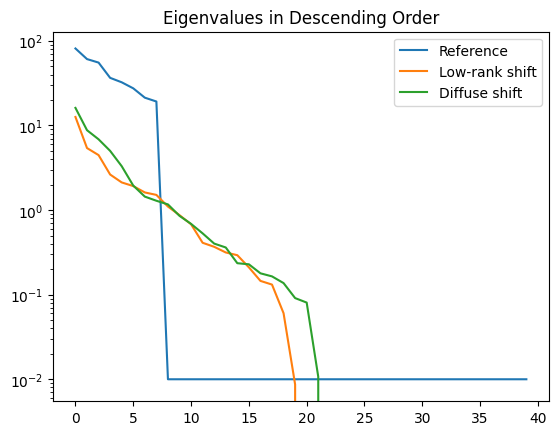

In [127]:

plt.title("Eigenvalues in Descending Order")
plt.semilogy(eig0, label='Reference')
plt.semilogy(eig_lr, label='Low-rank shift')
plt.semilogy(eig_dense, label='Diffuse shift')
plt.legend()
plt.show()


### <b>Step 3: Quantify “significant change”</b>
Define an eigenvalue as significantly changed if it differs from the corresponding eigenvalue of the Reference Covariance Matrix ​
  by more than a fixed threshold (e.g., 10% relative difference).

Using this criterion:

    Count how many eigenvalues change significantly in the low-rank case.

    Count how many eigenvalues change significantly in the diffuse case.

Report these numbers explicitly.

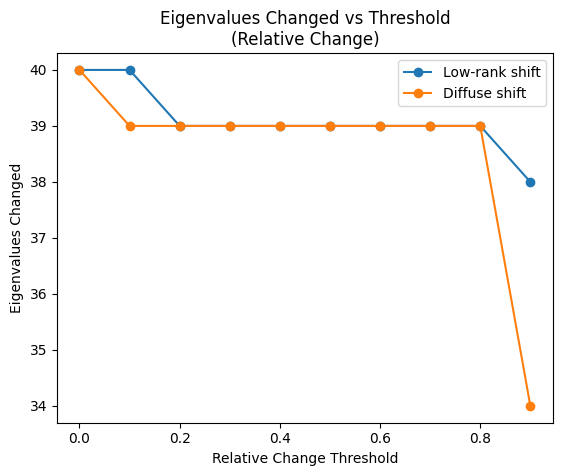

In [128]:
'''
    Relative change formula:  Rel_Change = abs( eigen_new - eigen_old) / abs(eigen_old))
'''

# Plot eigenvalues changed per threshold.
eigen_lr_count = []
eigen_dense_count = []
eigen_thresholds = []


# Run range of thresholds to find reasonable one.
for eig_thresh  in range(0,10,1):

    # Scale threshold.
    eig_thresh = eig_thresh * 0.1

    # Find significant change by list comprehension.
    eig_sig_lr = ((abs(eig_lr - eig0)) / abs(eig0) > eig_thresh).sum()
    eig_sig_dense = ((abs(eig_dense - eig0)) / abs(eig0) > eig_thresh).sum()

    # Store results for plotting.
    eigen_thresholds.append(eig_thresh)
    eigen_lr_count.append(eig_sig_lr)
    eigen_dense_count.append(eig_sig_dense)


# Plot eigen counts per threshold.
plt.title("Eigenvalues Changed vs Threshold\n(Relative Change)")
plt.xlabel("Relative Change Threshold")
plt.ylabel("Eigenvalues Changed")

plt.plot(eigen_thresholds, eigen_lr_count, marker='o', label='Low-rank shift')
plt.plot(eigen_thresholds, eigen_dense_count, marker='o', label='Diffuse shift')

plt.legend()
plt.show()


In [122]:
# Set threshold to 35% relative change per plot above.

eign_threshold = 0.35

# Find significant change by list comprehension.
sig_eign_lr = ((abs(eig_lr - eig0)) / abs(eig0) > eign_threshold).sum()
sig_eign_dense = ((abs(eig_dense - eig0)) / abs(eig0) > eign_threshold).sum()

print("\n\n")
print(f"There are {sig_eign_lr} eigenvalues that changed significantly in the Low-Rank Matrix.  Threshold from baseline: {eign_threshold * 100:.1f}%")
print(f"There are {sig_eign_dense} eigenvalues that changed significantly in the Diffuse Matrix.  Threshold from baseline: {eign_threshold * 100:.1f}%")





There are 3 eigenvalues that changed significantly in the Low-Rank Matrix.  Threshold from baseline: 35.0%
There are 8 eigenvalues that changed significantly in the Diffuse Matrix.  Threshold from baseline: 35.0%


### <b>Step 4: Interpret the results </b>

Answer the following questions in complete sentences:

    1. In the low-rank case, how many eigenvalues change substantially, and how does this number relate to the rank of the coefficient modification?

    2. In the diffuse case, why are many eigenvalues affected, even though the overall magnitude of the change is the same?

    3. How do these observations illustrate the idea that matrix rank limits the number of variance directions that can change?
    

Your explanation should explicitly reference:
    eigenvalues,
    rank,
    and geometric directions of variance.

In [123]:
# Calculate the rank of the Coefficient Modifications.  After some research I believe this is the rank of the difference matrix: A' - A.

# Calculate Difference Matrix.
rank_lr = np.linalg.matrix_rank(S_lr - Sigma0)
rank_dense = np.linalg.matrix_rank(S_dense - Sigma0)

print(f"The rank of the Coefficient Modification for:\n\n\tSigma0:  None.  This is our reference baseline.\n\n\tLow-Rank: {rank_lr}\n\n\tDense Case: {rank_dense}")



The rank of the Coefficient Modification for:

	Sigma0:  None.  This is our reference baseline.

	Low-Rank: 40

	Dense Case: 40


In [124]:
# Check rank for Low-Rank and Dense.
rank_sigma0 = np.linalg.matrix_rank(Sigma0)
rank_lr = np.linalg.matrix_rank(S_lr)
rank_dense = np.linalg.matrix_rank(S_dense)

print(f"Rank of Matrices:\n\n\tSigma:  {rank_sigma0}\n\n\tLow-Rank: {rank_lr}\n\n\tDense Case: {rank_dense}")

Rank of Matrices:

	Sigma:  40

	Low-Rank: 40

	Dense Case: 40


1)  In the Low-Rank case 39 eigenvalues changed substantially from the Reference Covariance Matrix with a threshold of 39% deviation.  The rank of the Coefficient Modification appears to be the same between each modifying case as measured by Rank(A' -A).  In fact, plotting number of significant eigenvalue changes per threshold showed that the relative change from baseline almost matches exactly between each case (Low-Rank and Dense).

2)  In the Diffuse Case the same number of eigenvalues was changed as in the Low-Rank case.  This may indicate that there is a problem with the program.  Or, that the Diffuse Case and Low-Rank Gaussians have the same rank.